In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import bokeh.palettes
import matplotlib.ticker as ticker

# font 
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
})

base_path = "/tmp/plots/"

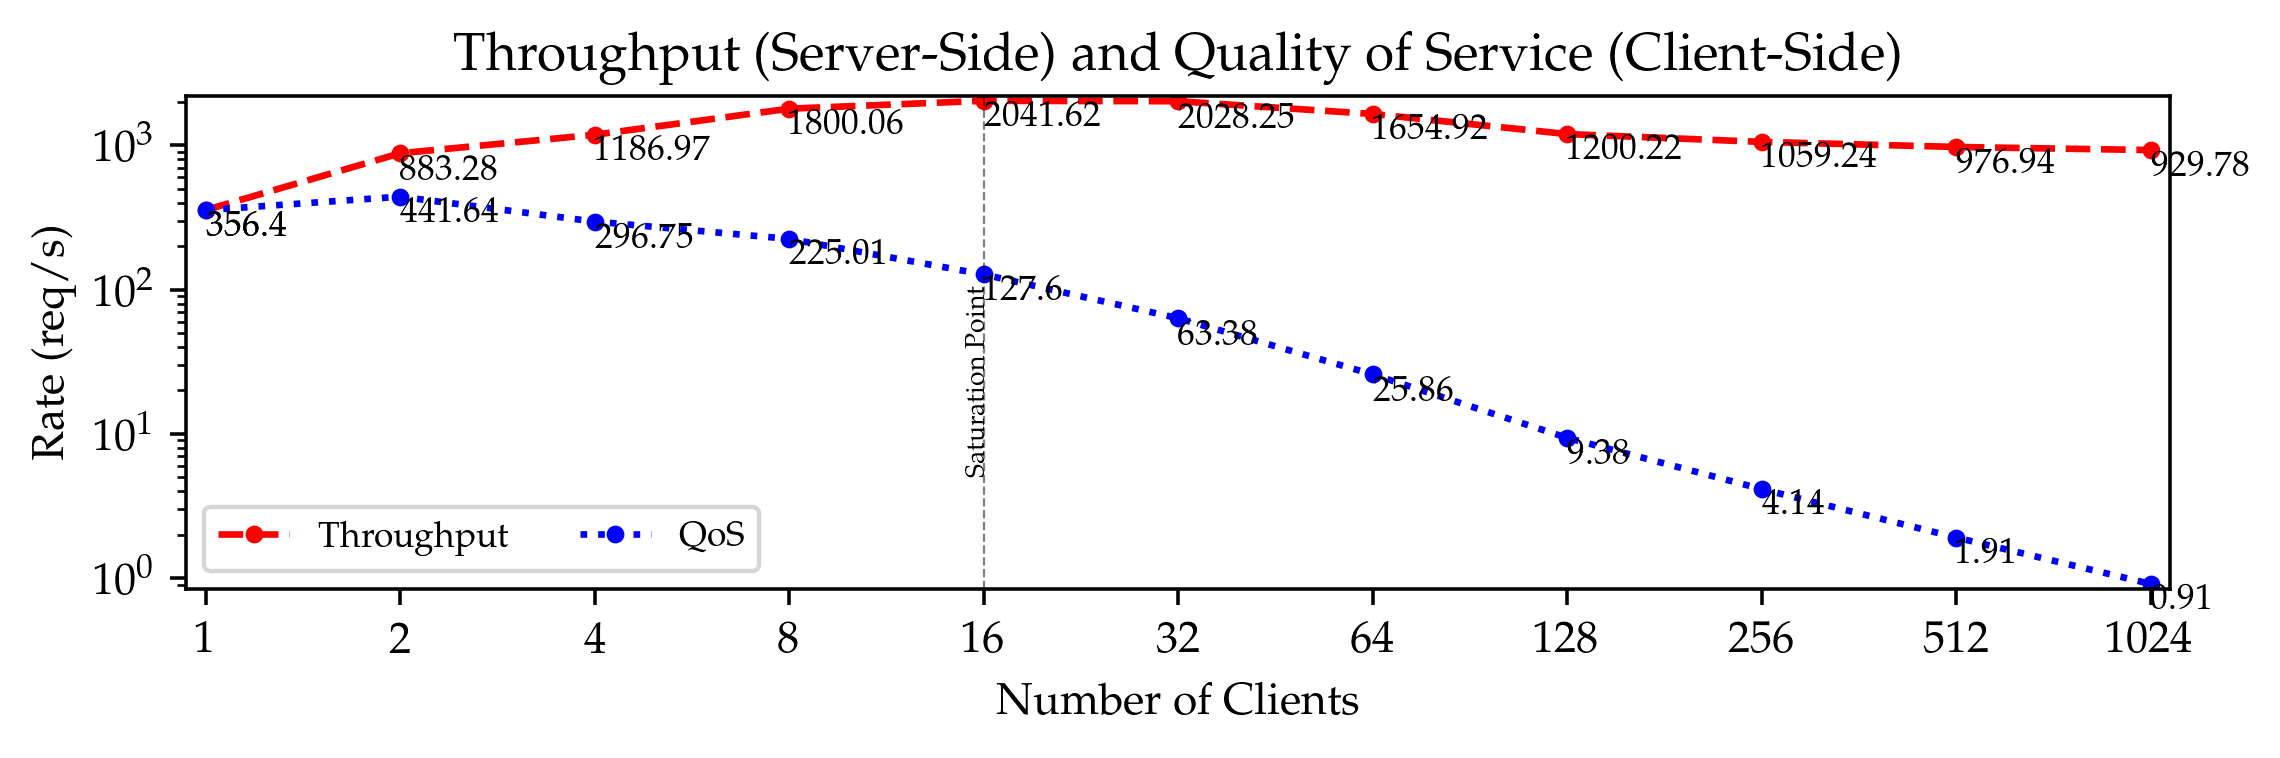

In [2]:
throughput = [356.40, 883.28, 1186.97, 1800.06, 2041.62, 2028.25, 1654.92, 1200.22, 1059.24, 976.94, 929.78]
quality_of_service = [356.40, 441.64, 296.75, 225.01, 127.60, 63.38, 25.86, 9.38, 4.14, 1.91, 0.91]

# x is 2**opt
x = [2 ** i for i in range(len(throughput))]

fig, ax = plt.subplots(1, 1, figsize=(8, 2), dpi=320)

ax.plot(x, throughput, label='Throughput', color='red', marker='.', linestyle='--')
ax.plot(x, quality_of_service, label='QoS', color='blue', marker='.', linestyle=':')

# x axis is log2 scale
plt.xscale('log', base=2)

# show x ticks for each point as 2**opt
plt.xticks(x, x)

# saturation point
plt.axvline(x=2 ** 4, color='black', linestyle='--', linewidth=0.5, alpha=0.5)
# write saturation point
ax.text(2 ** 4 - 1, 5, 'Saturation Point', color='black', fontsize=6, verticalalignment='bottom', rotation=90)

plt.yscale('log')

# zero margin right, bottom, left
plt.margins(0.01)

# show grid
# plt.grid(True)

# write the value of each point on the bottom of the point
for i, v in enumerate(throughput):
    ax.text(x[i], v, str(v), color='black', fontsize=8, verticalalignment='top')

for i, v in enumerate(quality_of_service):
    ax.text(x[i], v, str(v), color='black', fontsize=8, verticalalignment='top')

ax.set_xlabel('Number of Clients')
ax.set_ylabel('Rate (req/s)')
ax.set_title('Throughput (Server-Side) and Quality of Service (Client-Side)')

ax.legend(loc='lower left',
          ncol=2,
          # frameon=False,
          fancybox=True,
          fontsize=8)
# bbox_to_anchor=(0.5, 1.2),
# bbox_transform=ax.transAxes)

plt.savefig('throughput_qos.pdf', bbox_inches='tight')

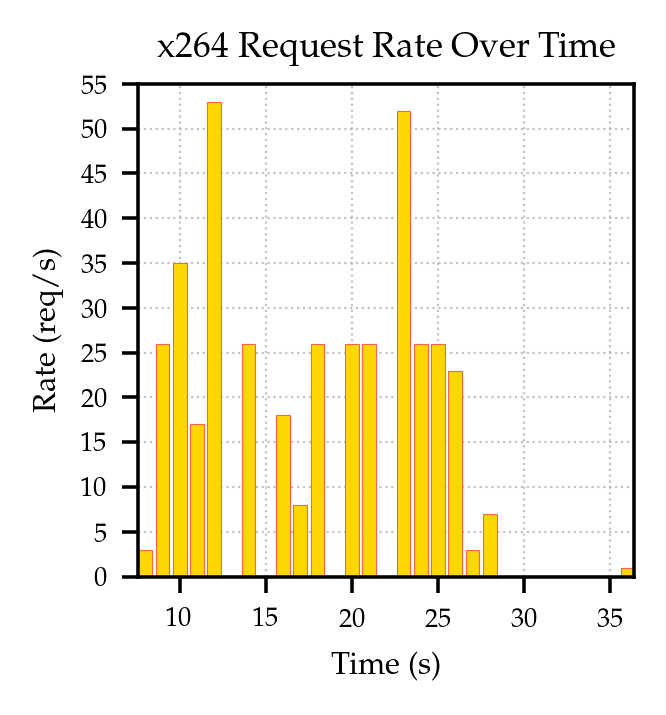

In [3]:
data = [(8, 3), (9, 26), (10, 35), (11, 17), (12, 53), (14, 26), (16, 18), (17, 8), (18, 26), (20, 26), (21, 26),
        (23, 52), (24, 26), (25, 26), (26, 23), (27, 3), (28, 7), (36, 1)]
# for the x that we don't have value put zero
x = [i for i in range(0, data[-1][0] + 1)]
y = [0 for i in range(0, data[-1][0] + 1)]
for i in range(len(data)):
    y[data[i][0]] = data[i][1]

x, y = zip(*data)

fig, ax = plt.subplots(1, 1, figsize=(2, 2), dpi=320)

# bar plot
ax.bar(x, y, color='gold', width=.8, edgecolor='tomato', linewidth=0.25, zorder=2)

# set y limit
plt.ylim(0, max(y) % 5 + max(y) - 5)
plt.xticks([i for i in range(0, max(x), 5)], fontsize=6)
plt.yticks([i for i in range(0, max(y) + 5, 5)], fontsize=6)

# zero margin
plt.margins(0)

# show grid in dash
plt.grid(True, linestyle=':', linewidth=0.5, alpha=0.75)

ax.set_xlabel('Time (s)', fontsize=7)
ax.set_ylabel('Rate (req/s)', fontsize=7)

# title 
ax.set_title('x264 Request Rate Over Time', fontsize=8)

plt.savefig('x264_rate.pdf', bbox_inches='tight')

plt.show()